# PINNs vs Data Driven Neural Networks for Fluid Flow

### Objective
Evaluate whether incorporating physical constraints improves prediction accuracy when training data are sparse.

## Governing Equation (Fluid Flow)
I am going to use the simplified 1-D flow equation instead of full Navier–Stokes.

A practical choice is the advection–diffusion equation: https://en.wikipedia.org/wiki/Convection%E2%80%93diffusion_equation. 

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x}
= D \frac{\partial^2 u}{\partial x^2}
$$

Meaning of each term
- $u(x,t)$: transported scalar field (e.g., pollutant concentration, chlorine level, temperature)

- $c$: advection velocity (flow speed of the water)

- $D$: diffusion coefficient (mixing/dispersion)

- $\frac{\partial u}{\partial t}$: rate of change of concentration over time

- $c \frac{\partial u}{\partial x}$: transport due to bulk flow of the fluid

- $D \frac{\partial^2 u}{\partial x^2}$: spreading due to diffusion or turbulent mixing

## Two Models to Compare

### Model 1 - Standard Neural Network 
Train a neural network to learn,
$u(x, t) = NN(x, t)$, 
using only data points. 

Loss:

$\frac{1}{N} \sum({u_{pred} - u_{data}})^2$


### Model 2 - Physics Informed Neural Network
Use the same network,
$u(x, t) = NN(x, t)$,
but include the physics into the loss function.

Physics Loss:

$f(x, t) = \frac{du}{dt} + c \frac{du}{dx} - D \frac{du^2}{d^2x}$

$L_{physics} = \frac{1}{N_f} \sum_{i=1}^{N_f}{|f(x_i, t_i)|^2}$

$L = L_{data} + \lambda \times L_{physics}$, where lambda is a weighting parameter to control how much the physics constrains the system. 

## Initial and boundary conditions

For my initial condition I am going to use Gausian Pulse:

$u(x, 0) = e^{-50(x-0.5)^2}$

This can represent a localised pollutant spill at the centre of the river, diffusion spreads the plume, and advection moves it downstream. 

The advantages of this are: that it is a smooth function, produces easily interpretable results, widely used in transport modelling.

## Exact Solution 

$$
u(x,t) = \frac{1}{\sqrt{1+200 D t}} e^{- \frac{50(x-ct-0.5)^2}{1+200 D t}}
$$



In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## Define a standard fully-connected network in PyTorch

In [2]:

def exact_solution(c, D, x, t):
    """
    Analytical solution of the 1D advection–diffusion equation
    with Gaussian initial condition.
    """

    denom = 1 + 200*D*t
    prefactor = 1 / torch.sqrt(denom)

    exp_term = torch.exp(-50*(x - c*t - 0.5)**2 / denom)

    u = prefactor * exp_term

    return u

def initial_condition(x, c, D):
    """
    Gaussian initial condition for 1D advection–diffusion equation
    x: tensor of spatial points
    Returns u(x,0)
    """
    t0 = torch.zeros_like(x)  # t = 0
    u0 = exact_solution(c, D, x, t0)  # evaluate the exact solution at t=0
    return u0

def relative_l2_error(u_pred, u_true):
    return torch.norm(u_pred - u_true) / torch.norm(u_true)

class FCN(nn.Module):
    "Defines a standard fully-connected network in PyTorch"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Generate Observation Data

Advection velocity c: 1.0
Diffusion coefficient D: 0.01


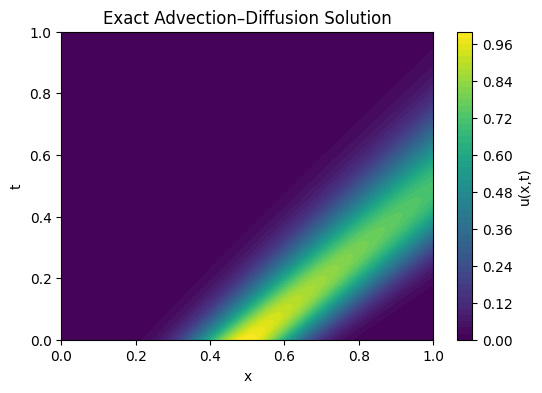

In [3]:
torch.manual_seed(123)

# physical parameters
c = 1.0
D = 0.01

print(f"Advection velocity c: {c}")
print(f"Diffusion coefficient D: {D}")


# --------------------------------------
# test grid (ground truth)
# --------------------------------------

x_test = torch.linspace(0,1,100)
t_test = torch.linspace(0,1,100)

X_test, T_test = torch.meshgrid(x_test, t_test, indexing="ij")

u_exact = exact_solution(c, D, X_test, T_test)

plt.figure(figsize=(6,4))
plt.contourf(X_test, T_test, u_exact, levels=50)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact Advection–Diffusion Solution")
plt.colorbar(label="u(x,t)")
plt.show()


# Track Error
X_eval = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
u_true = exact_solution(c, D, X_eval[:,0:1], X_eval[:,1:2])
u_true = u_true.reshape(100,100)


Step 0 | Relative L2 Error: 1.0613e+00


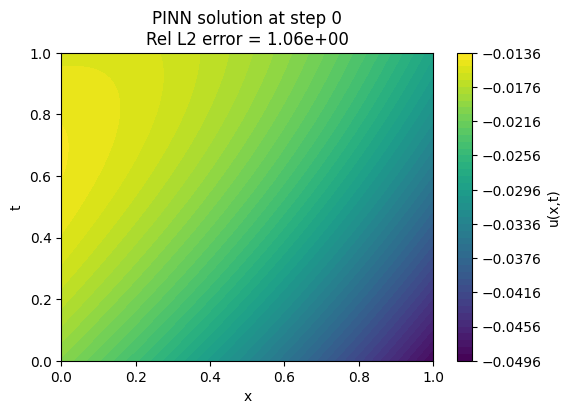

Step 5000 | Relative L2 Error: 8.8331e-02


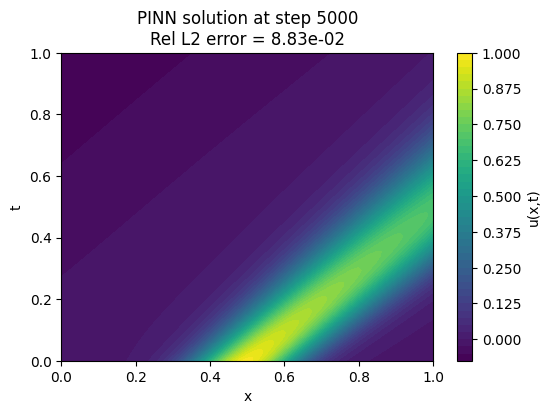

Step 10000 | Relative L2 Error: 6.5754e-02


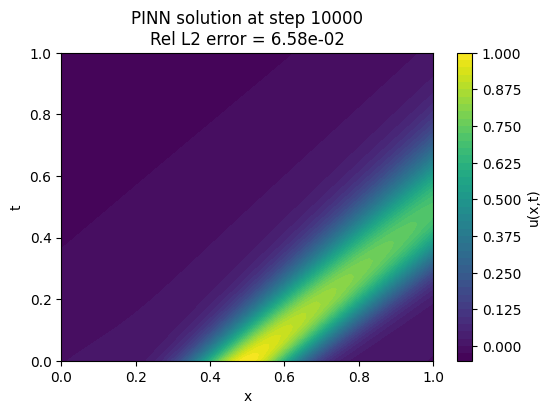

Step 15000 | Relative L2 Error: 5.5086e-02


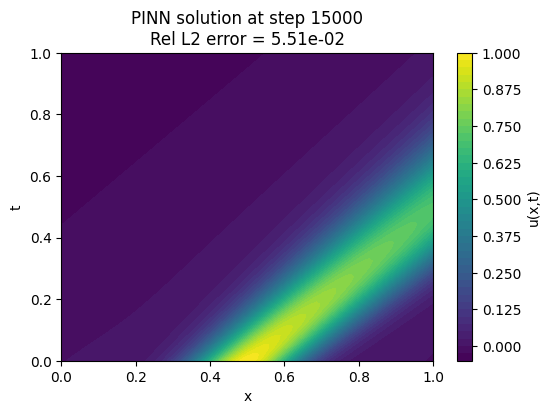

In [4]:
# define a neural network to train
pinn = FCN(2,1,32,3)

# Data points
N_obs = 20 # 20 - 50

x_obs = torch.rand(N_obs,1)
t_obs = torch.rand(N_obs,1)
u_obs = exact_solution(c, D, x_obs, t_obs) + 0.02*torch.randn_like(x_obs)
X_obs     = torch.cat([x_obs, t_obs], dim=1).requires_grad_(True)

# Physics Training points
N_physics =  1000 # 1000 - 10,000

x_physics = torch.rand(N_physics,1, requires_grad=True)
t_physics = torch.rand(N_physics,1, requires_grad=True)
X_physics = torch.cat([x_physics, t_physics], dim=1)

N_ic = 100 # 100 - 200

x_ic = torch.rand(N_ic, 1)
X_ic = torch.cat([x_ic, torch.zeros_like(x_ic)], dim=1)  # t=0
u_ic_target = initial_condition(x_ic, c, D)  # target values at t=0

# Track Error
X_eval = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
u_true = exact_solution(c, D, X_eval[:,0:1], X_eval[:,1:2])
u_true = u_true.reshape(100,100)

# optimiser
optimiser = torch.optim.Adam(pinn.parameters(), lr=1e-3)

for i in range(15001):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters:
    lambda1, lambda2 = 1e2, 1e3
    
    # compute data loss
    u_data = pinn(X_obs)   
    L_data = torch.mean((u_data - u_obs)**2)
    
    
    # physics loss
    u_physics = pinn(X_physics)
    
    grads = torch.autograd.grad(
        u_physics, X_physics, 
        torch.ones_like(u_physics), 
        create_graph=True
    )[0]
    
    dudx = grads[:,0:1]
    dudt = grads[:,1:2]
    
    d2udx2 = torch.autograd.grad(
        dudx, X_physics, 
        torch.ones_like(dudx), 
        create_graph=True
    )[0][:,0:1]
    
    f = dudt + c * dudx - D*d2udx2
    L_physics = torch.mean(f**2)
    
    
    # # Compute predicted values at initial points
    u_ic = pinn(X_ic)
    L_ic = torch.mean((u_ic  - u_ic_target)**2)
    
    
    
    # backpropagate joint loss, take optimiser step
    loss = L_data + lambda1 * L_physics + lambda2 * L_ic
    
    loss.backward()
    optimiser.step()


    # plot the result as training progresses
    if i % 5000 == 0:
        X_pred = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
        u_pred = pinn(X_pred).detach().reshape(100,100)

        error = relative_l2_error(u_pred, u_true)

        print(f"Step {i} | Relative L2 Error: {error.item():.4e}")

        plt.figure(figsize=(6,4))
        plt.contourf(X_test, T_test, u_pred, levels=50, cmap="viridis")
        plt.xlabel("x")
        plt.ylabel("t")
        plt.title(f"PINN solution at step {i}\nRel L2 error = {error.item():.2e}")
        plt.colorbar(label="u(x,t)")
        plt.show()


Step 0 | Relative L2 Error: 8.9188e-01


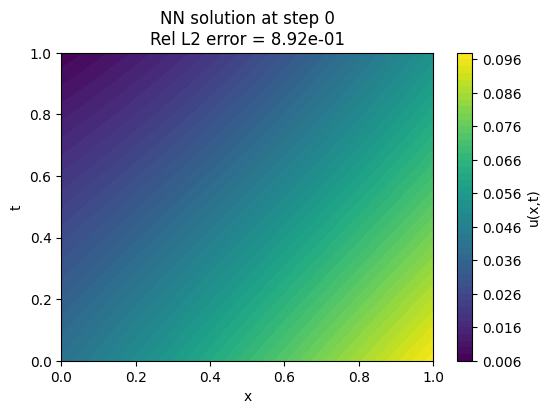

Step 5000 | Relative L2 Error: 4.9970e-02


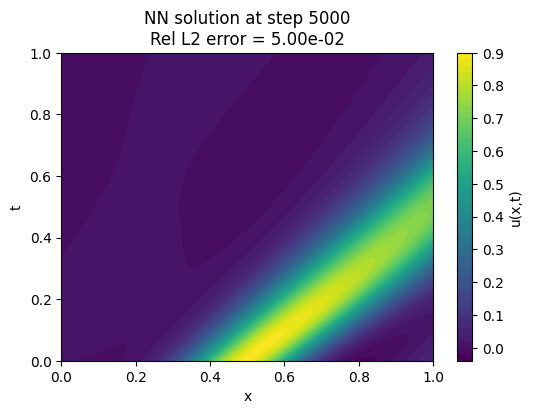

Step 10000 | Relative L2 Error: 5.2550e-02


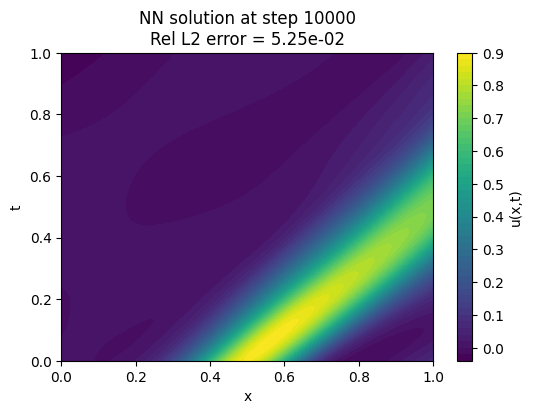

Step 15000 | Relative L2 Error: 7.0030e-02


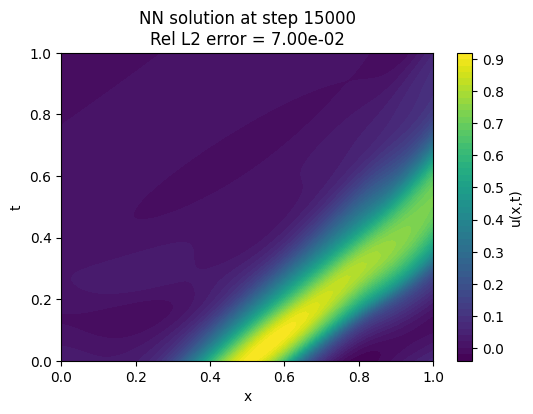

In [5]:
# define a neural network to train
nn = FCN(2,1,32,3)

# Data points
N_obs = 200 # 200 - 500

x_obs = torch.rand(N_obs,1)
t_obs = torch.rand(N_obs,1)
u_obs = exact_solution(c, D, x_obs, t_obs) + 0.02*torch.randn_like(x_obs)
X_obs     = torch.cat([x_obs, t_obs], dim=1).requires_grad_(True)

# Track Error
X_eval = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
u_true = exact_solution(c, D, X_eval[:,0:1], X_eval[:,1:2])
u_true = u_true.reshape(100,100)

# optimiser
optimiser = torch.optim.Adam(nn.parameters(), lr=1e-3)

for i in range(15001):
    optimiser.zero_grad()

    # compute data loss
    u = nn(X_obs)   
    L_data = torch.mean((u-u_obs)**2)
    
    # backpropagate joint loss, take optimiser step
    loss = L_data
    loss.backward()
    optimiser.step()


    # plot the result as training progresses
    if i % 5000 == 0:
        X_pred = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
        u_pred = nn(X_pred).detach().reshape(100,100)

        error = relative_l2_error(u_pred, u_true)

        print(f"Step {i} | Relative L2 Error: {error.item():.4e}")

        plt.figure(figsize=(6,4))
        plt.contourf(X_test, T_test, u_pred, levels=50, cmap="viridis")
        plt.xlabel("x")
        plt.ylabel("t")
        plt.title(f"NN solution at step {i}\nRel L2 error = {error.item():.2e}")
        plt.colorbar(label="u(x,t)")
        plt.show()
